# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A linear model is one that produces a prediction by performing a linear combination of the input vector. So linear models are linear in the weights applied to each input parameter.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)

The trick here is that it depends on how you handled the dummy variable when you're fitting the model. If you chose to leave the first category in and drop the intercept coefficient, then each coefficient $B$ is associated with an absolute change of $B$ in the output (essentially creating a variable intercept based on the value of the one-hot vector). If you chose to drop the first cateogory and retain the intercept, then the intercept value $B_0$, is the absolute change associated with the dropped category, and the other coeficients represent the change *relative* to that baseline.

3. Can linear regression be used for classification? Explain why, or why not.

It is used for classification in the sense that for a logistic regression the first step is to perform a linear regression. However, using just a linear model for a classification problem is probably a bad idea since it will not always predict 0s, 1s, or some number in between. 

4. What are signs that your linear model is over-fitting?

As with any model overfitting is common when your traning error is much lower than validation or testing error. For linear models specifically, having very large coefficients is a good sign that you are overfitting your data (this is a good reason to regularize). 

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multi-colinearity is used to discover the relationships between variables in a complex linear model. The steps are as follows:

1. Regress $y$ on all the variables besides $x_k$, and save the residuals $r_y$
2. Regress $x_k$ on all the variables besides $x_k$, and save the residuals $r_x$
3. Plot $r_y$ against $r_x$

The idea of this is that if $x_k$ can be described by the other variables, then it will be fully explained by them in step 2. This would result in residuals close to 0. If however, the other variables do not contain the information found in $x_k$, there will be non-zero residuals, and potentially a clear relationship between $r_y$ and $r_x$.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can easily do this by including other non-linearly generated features to regress on. For instance you could incude powers of $X$ and/or logarithmic transformations in your features.

7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

The intercept is the value of the prediction when the input vector is entirely 0. It represents the baseline from which numbers will be added and subtracted based on the values of the input vector.

A lope coefficient for a variable represents how much that variable affects the prediction (small vs large magnitude), and wether it affects the prediction positively or negatively.

The coefficient for a dummy variable represents how much to add or subtract from the prediction when the dummy variable is 1.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

Average Price and Review Score by Neighbourhood:
  Neighbourhood        Price  Review Scores Rating
2      Manhattan  183.664286             91.801496
4  Staten Island  146.166667             90.843750
1       Brooklyn  127.747378             92.363497
3         Queens   96.857233             91.549057
0          Bronx   75.276498             91.654378

Most expensive borough on average: Manhattan


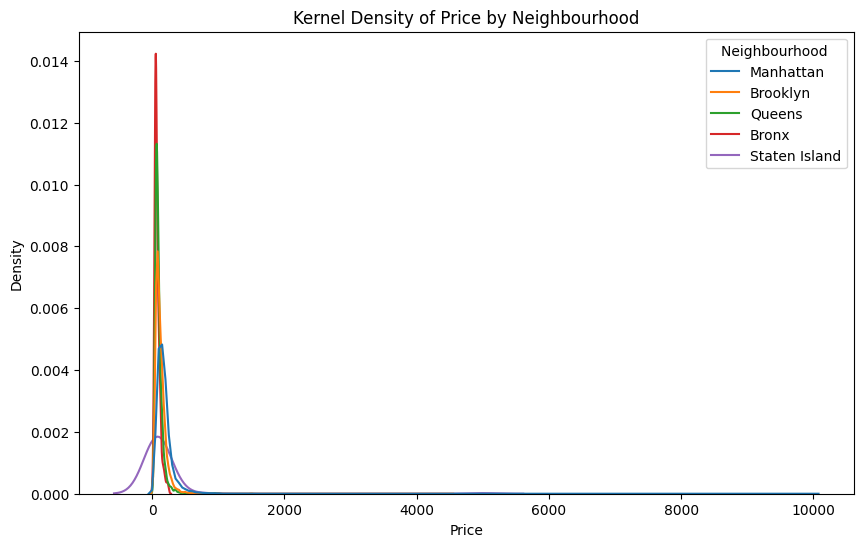

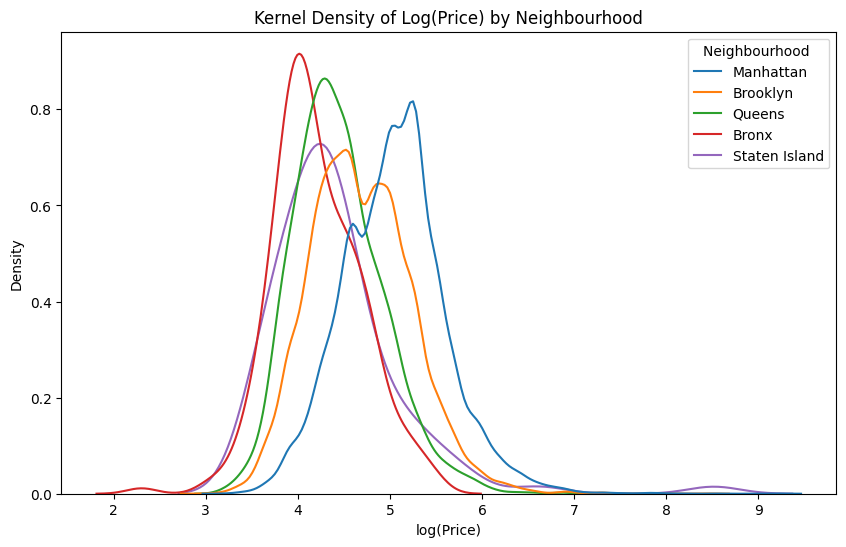

In [1]:
# Load `./data/Q1_clean.csv`. The data include
## - `Review Scores Rating`: The average rating for the property
# - `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
# - `Property Type`: The kind of dwelling
# - `Room Type`: The kind of space being rented

# load data
import pandas as pd
import numpy as np
import seaborn as sns
df = pd.read_csv("./data/Q1_clean.csv")


# 1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.

import matplotlib.pyplot as plt

# average price and review score by borough
avg_by_neighborhood = (
    df.groupby("Neighbourhood ", as_index=False)[["Price", "Review Scores Rating"]]
      .mean()
      .sort_values("Price", ascending=False)
)

# The most expensive neighborhood is Manhattan (go figure!)

print("Average Price and Review Score by Neighbourhood:")
print(avg_by_neighborhood)

most_expensive = avg_by_neighborhood.iloc[0]["Neighbourhood "]
print(f"\nMost expensive borough on average: {most_expensive}")

# log price
df["log_price"] = np.log(df["Price"])

# KDE: Price by neighbourhood
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="Price", hue="Neighbourhood ", common_norm=False, fill=False)
plt.title("Kernel Density of Price by Neighbourhood")
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()

# KDE: Log(Price) by neighbourhood
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="log_price", hue="Neighbourhood ", common_norm=False, fill=False)
plt.title("Kernel Density of Log(Price) by Neighbourhood")
plt.xlabel("log(Price)")
plt.ylabel("Density")
plt.show()

# 6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
# 7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?



In [2]:
from sklearn.linear_model import LinearRegression

# 2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?

X_nbhd = pd.get_dummies(df["Neighbourhood "], drop_first=False).astype(int)
y = df["Price"]

model_no_intercept = LinearRegression(fit_intercept=False)
model_no_intercept.fit(X_nbhd, y)

coef_df = pd.DataFrame({
    "Neighbourhood ": X_nbhd.columns,
    "coef_no_intercept": model_no_intercept.coef_
})

comparison = coef_df.merge(
    avg_by_neighborhood[["Neighbourhood ", "Price"]].rename(columns={"Price": "avg_price_part1"}),
    on="Neighbourhood ",
    how="left"
)
comparison["difference"] = comparison["coef_no_intercept"] - comparison["avg_price_part1"]
comparison = comparison.sort_values("coef_no_intercept", ascending=False)

print(comparison)

# The coeficients and the average prices are nearly identical! 

  Neighbourhood   coef_no_intercept  avg_price_part1    difference
2      Manhattan         183.664286       183.664286  2.557954e-13
4  Staten Island         146.166667       146.166667  0.000000e+00
1       Brooklyn         127.747378       127.747378  5.684342e-14
3         Queens          96.857233        96.857233  0.000000e+00
0          Bronx          75.276498        75.276498 -1.421085e-14

All close to group means?: True


In [3]:
# 3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?

X_nbhd_drop = pd.get_dummies(df["Neighbourhood "], drop_first=True).astype(int)

model_with_intercept = LinearRegression(fit_intercept=True)
model_with_intercept.fit(X_nbhd_drop, y)

coef_df_intercept = pd.DataFrame({
    "Neighbourhood ": X_nbhd_drop.columns,
    "coef_with_intercept": model_with_intercept.coef_
})

print(f"Intercept: {model_with_intercept.intercept_:.4f}")
print(f"(This is the average price for the dropped category: Bronx = {avg_by_neighborhood[avg_by_neighborhood['Neighbourhood '] == 'Bronx']['Price'].values[0]:.4f})")
print()
print(coef_df_intercept)

print("\nadd intercepts to get originals:")
print(f"Bronx (baseline) = intercept = {model_with_intercept.intercept_:.4f}")
for _, row in coef_df_intercept.iterrows():
    print(f"{row['Neighbourhood ']}: {model_with_intercept.intercept_:.4f} + {row['coef_with_intercept']:.4f} = {model_with_intercept.intercept_ + row['coef_with_intercept']:.4f}")

Intercept: 75.2765
(This is the average price for the dropped category: Bronx = 75.2765)

  Neighbourhood   coef_with_intercept
0       Brooklyn            52.470881
1      Manhattan           108.387789
2         Queens            21.580735
3  Staten Island            70.890169

To get the no-intercept coefficients from these, add the intercept to each coefficient:
  Bronx (baseline) = intercept = 75.2765
  Brooklyn: 75.2765 + 52.4709 = 127.7474
  Manhattan: 75.2765 + 108.3878 = 183.6643
  Queens: 75.2765 + 21.5807 = 96.8572
  Staten Island: 75.2765 + 70.8902 = 146.1667


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

# 4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

nbhd_dummies = pd.get_dummies(df["Neighbourhood "], prefix="Neighbourhood", drop_first=True)
X_q4 = pd.concat([df["Review Scores Rating"], nbhd_dummies], axis=1)
y_q4 = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X_q4, y_q4, test_size=0.2, random_state=42)

model_q4 = LinearRegression()
model_q4.fit(X_train, y_train)

y_pred = model_q4.predict(X_test)
r2_test = model_q4.score(X_test, y_test)
rmse_test = root_mean_squared_error(y_test, y_pred)

print(f"R² (test): {r2_test:.4f}")
print(f"RMSE (test): {rmse_test:.4f}")

coef_map = pd.Series(model_q4.coef_, index=X_q4.columns)
coef_review = coef_map["Review Scores Rating"]
print(f"\nCoefficient on Review Scores Rating: {coef_review:.4f}")

nbhd_cols = [col for col in coef_map.index if col.startswith("Neighbourhood_")]
nbhd_effects = {col.replace("Neighbourhood_", ""): coef_map[col] for col in nbhd_cols}
nbhd_effects["Bronx"] = 0.0
most_expensive_neighbourhood = max(nbhd_effects, key=nbhd_effects.get)

# The most expensive property you can get is in Manhattan with a high rating.


R² (test): 0.0459
RMSE (test): 140.9182

Coefficient on Review Scores Rating: 1.2119

Most expensive neighbourhood: Manhattan
Neighbourhood effects: {'Brooklyn': np.float64(51.55597031072887), 'Manhattan': np.float64(107.41355278437642), 'Queens': np.float64(20.198573013435816), 'Staten Island': np.float64(23.454672190191555), 'Bronx': 0.0}


In [ ]:
# 5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

prop_dummies = pd.get_dummies(df["Property Type"], prefix="PropertyType", drop_first=True).astype(int)
X_q5 = pd.concat([df["Review Scores Rating"], nbhd_dummies, prop_dummies], axis=1)
y_q5 = df["Price"]

X_train5, X_test5, y_train5, y_test5 = train_test_split(X_q5, y_q5, test_size=0.2, random_state=42)

model_q5 = LinearRegression()
model_q5.fit(X_train5, y_train5)

y_pred5 = model_q5.predict(X_test5)
r2_test5 = model_q5.score(X_test5, y_test5)
rmse_test5 = root_mean_squared_error(y_test5, y_pred5)

print(f"R² (test): {r2_test5:.4f}")
print(f"RMSE (test): {rmse_test5:.4f}")

coef_map5 = pd.Series(model_q5.coef_, index=X_q5.columns)
coef_review5 = coef_map5["Review Scores Rating"]
print(f"\nCoefficient on Review Scores Rating: {coef_review5:.4f}")

prop_cols = [col for col in coef_map5.index if col.startswith("PropertyType_")]
prop_effects = {col.replace("PropertyType_", ""): coef_map5[col] for col in prop_cols}

prop_effects["Apartment"] = 0.0
most_expensive_property = max(prop_effects, key=prop_effects.get)
print(f"\nMost expensive property type: {most_expensive_property}")
print(f"Coefficient: {prop_effects[most_expensive_property]:.4f}")

# The most expensive property type would be a highly rated, manhattan bungalow.



R² (test): 0.0542
RMSE (test): 140.3027

Coefficient on Review Scores Rating: 1.2010

Most expensive property type: Bungalow
Coefficient: 83.9724


*What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.*

In part 4, the rating coefficient is telling us how much to change the price while holding constant the neighborhood. In part 5, it also holds the property type constant. If it changes this means that there is probably some correlation between the rating and the property type that needed to be accounted for in the part 5 regression.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  
<class 'pandas.DataFrame'>
Range

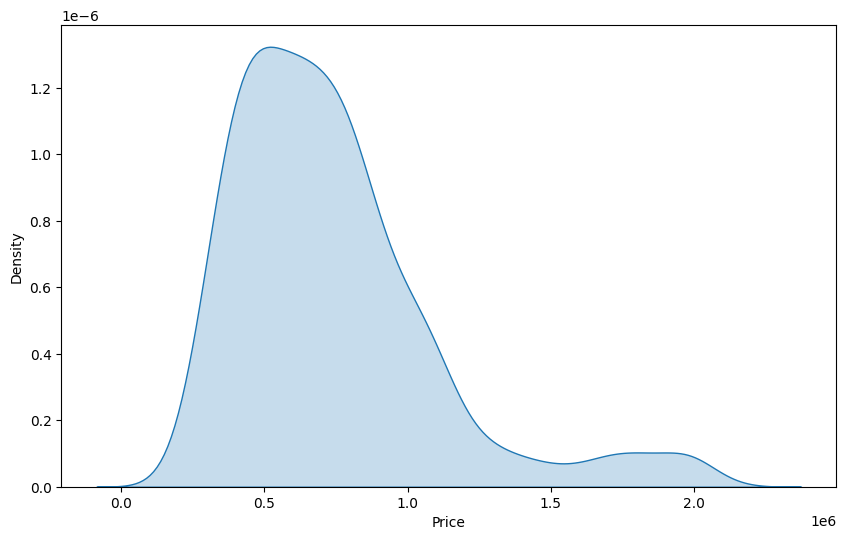


most expensive brand: Chevrolet


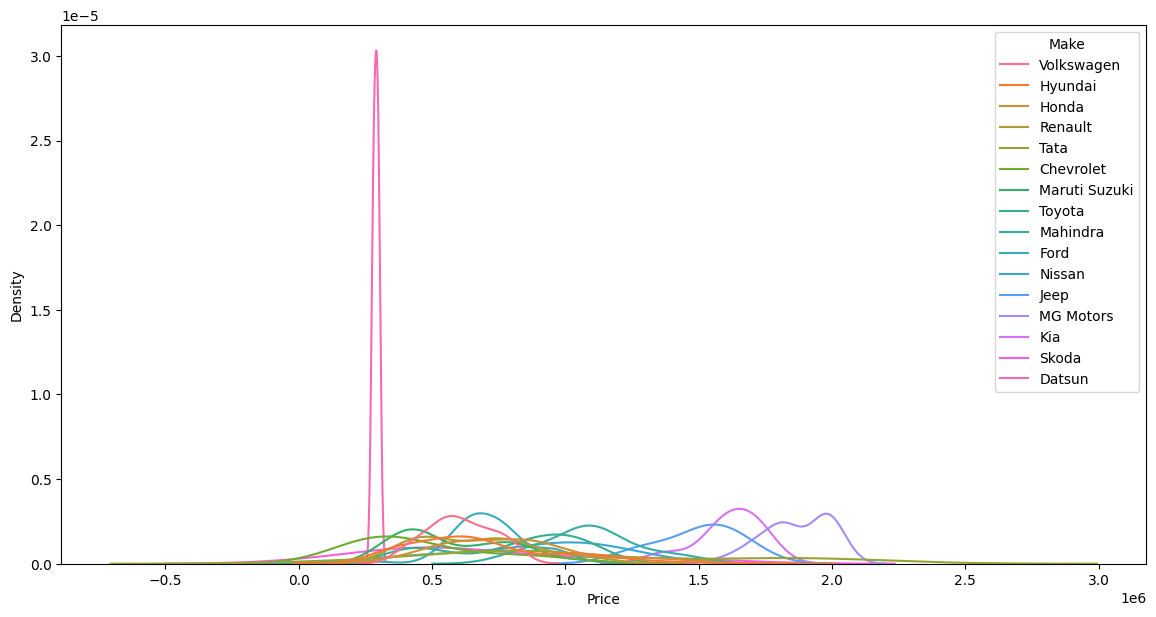

R² (train): 0.3436, RMSE (train): 294798.91
R² (test): 0.3029, RMSE (test): 287741.37

R² (test): 0.7100, RMSE (test): 185584.68

Model 3: Combined (numeric + categorical)
R² (test): 0.8166, RMSE (test): 147603.78

Summary:
numeric only: R² = 0.3029, RMSE = 287741.37
categorical only: R² = 0.7100, RMSE = 185584.68
combined: R² = 0.8166, RMSE = 147603.78

polynomial feature model: 
Degree 1: R^2 train=0.3436, R^2 test=0.3029, RMSE train=294798.91, RMSE test=287741.37
Degree 2: R^2 train=0.3648, R^2 test=0.3053, RMSE train=290009.58, RMSE test=287229.81
Degree 3: R^2 train=0.3629, R^2 test=0.3065, RMSE train=290434.49, RMSE test=286993.06
Degree 4: R^2 train=0.3698, R^2 test=0.3113, RMSE train=288856.52, RMSE test=285995.54
Degree 5: R^2 train=0.3676, R^2 test=0.2962, RMSE train=289365.60, RMSE test=289119.42
Degree 6: R^2 train=0.3622, R^2 test=0.2828, RMSE train=290593.05, RMSE test=291858.76
Degree 7: R^2 train=0.2947, R^2 test=0.2175, RMSE train=305582.31, RMSE test=304839.70
Degree 

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
# **Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

 #  - `Price`, `Color`, `Seating_Capacity`
 #  - `Body_Type`: crossover, hatchback, muv, sedan, suv
 #  - `Make`, `Make_Year`: The brand of car and year produced
 #  - `Mileage_Run`: The number of miles on the odometer
 #  - `Fuel_Type`: Diesel or gasoline/petrol
 #  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

 #  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.

cars = pd.read_csv("./data/cars_hw.csv")
print(cars.head())
print(cars.info())
print(cars.describe())

cars = cars.drop_duplicates()
cars = cars.dropna()

# check for outliers in price and mileage using IQR
for col in ["Price", "Mileage_Run"]:
    Q1 = cars[col].quantile(0.25)
    Q3 = cars[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    before = len(cars)
    cars = cars[(cars[col] >= lower) & (cars[col] <= upper)]

# apply log/arcsinh transformations to price and mileage
cars["log_Price"] = np.log1p(cars["Price"])
cars["log_Mileage_Run"] = np.log1p(cars["Mileage_Run"])

print(cars.describe())

# looks pretty good now!

 #  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?

print(cars["Price"].describe())

plt.figure(figsize=(10, 6))
sns.kdeplot(data=cars, x="Price", fill=True)
plt.show()

price_by_make = cars.groupby("Make")["Price"].describe()

most_expensive_make = price_by_make.index[0]
print(f"\nmost expensive brand: {most_expensive_make}")

plt.figure(figsize=(14, 7))
sns.kdeplot(data=cars, x="Price", hue="Make", common_norm=False, fill=False)
plt.show()

 #  3. Split the data into an 80% training set and a 20% testing set.

X = cars.drop(columns=["Price", "log_Price", "Unnamed: 0"])
y = cars["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 #  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?

# numeric variables
numeric_cols = ["Seating_Capacity", "Make_Year", "Mileage_Run", "log_Mileage_Run"]
X_train_numeric = X_train[numeric_cols]
X_test_numeric = X_test[numeric_cols]

model1 = LinearRegression()
model1.fit(X_train_numeric, y_train)

y_pred_train1 = model1.predict(X_train_numeric)
y_pred_test1 = model1.predict(X_test_numeric)

r2_train1 = model1.score(X_train_numeric, y_train)
r2_test1 = model1.score(X_test_numeric, y_test)
rmse_train1 = root_mean_squared_error(y_train, y_pred_train1)
rmse_test1 = root_mean_squared_error(y_test, y_pred_test1)

print(f"R² (train): {r2_train1:.4f}, RMSE (train): {rmse_train1:.2f}")
print(f"R² (test): {r2_test1:.4f}, RMSE (test): {rmse_test1:.2f}\n")

# categorical variables 
categorical_cols = ["Color", "Body_Type", "Make", "Fuel_Type", "Transmission", "Transmission_Type"]
X_train_cat = pd.get_dummies(X_train[categorical_cols], drop_first=True)
X_test_cat = pd.get_dummies(X_test[categorical_cols], drop_first=True)

X_test_cat = X_test_cat.reindex(columns=X_train_cat.columns, fill_value=0)

model2 = LinearRegression()
model2.fit(X_train_cat, y_train)

y_pred_test2 = model2.predict(X_test_cat)
r2_test2 = model2.score(X_test_cat, y_test)
rmse_test2 = root_mean_squared_error(y_test, y_pred_test2)

print(f"R² (test): {r2_test2:.4f}, RMSE (test): {rmse_test2:.2f}\n")

# combined
X_train_combined = pd.concat([X_train_numeric, X_train_cat], axis=1)
X_test_combined = pd.concat([X_test_numeric, X_test_cat], axis=1)

model3 = LinearRegression()
model3.fit(X_train_combined, y_train)

y_pred_test3 = model3.predict(X_test_combined)
r2_test3 = model3.score(X_test_combined, y_test)
rmse_test3 = root_mean_squared_error(y_test, y_pred_test3)

print("Model 3: Combined (numeric + categorical)")
print(f"R² (test): {r2_test3:.4f}, RMSE (test): {rmse_test3:.2f}\n")

# Comparison
print("Summary:")
print(f"numeric only: R² = {r2_test1:.4f}, RMSE = {rmse_test1:.2f}")
print(f"categorical only: R² = {r2_test2:.4f}, RMSE = {rmse_test2:.2f}")
print(f"combined: R² = {r2_test3:.4f}, RMSE = {rmse_test3:.2f}")

# The best score is the combined model, followed by categorical, and then numeric. The combined model has an R^2 of about .10 higher than just using categorical.

 #  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?

print("\npolynomial feature model: ")
results = []
best_r2 = -np.inf
best_model_poly = None
best_degree = None
best_y_pred = None

for degree in range(1, 10):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_numeric)
    X_test_poly = poly.transform(X_test_numeric)
    
    model_poly = LinearRegression()
    model_poly.fit(X_train_poly, y_train)
    
    y_pred_train_poly = model_poly.predict(X_train_poly)
    y_pred_test_poly = model_poly.predict(X_test_poly)
    
    r2_train_poly = model_poly.score(X_train_poly, y_train)
    r2_test_poly = model_poly.score(X_test_poly, y_test)
    rmse_train_poly = root_mean_squared_error(y_train, y_pred_train_poly)
    rmse_test_poly = root_mean_squared_error(y_test, y_pred_test_poly)
    
    results.append({
        'degree': degree,
        'r2_train': r2_train_poly,
        'r2_test': r2_test_poly,
        'rmse_train': rmse_train_poly,
        'rmse_test': rmse_test_poly
    })
    
    if r2_test_poly > best_r2:
        best_r2 = r2_test_poly
        best_model_poly = model_poly
        best_degree = degree
        best_y_pred = y_pred_test_poly
    
    print(f"Degree {degree}: R^2 train={r2_train_poly:.4f}, R^2 test={r2_test_poly:.4f}, "
          f"RMSE train={rmse_train_poly:.2f}, RMSE test={rmse_test_poly:.2f}")

print(f"\nBest polynomial degree: {best_degree}, R^2={best_r2:.4f}")
print(f"Comparison - Best combined model (part 4): R^2={r2_test3:.4f}, RMSE={rmse_test3:.2f}")

# The R^2 begins to go lower at a degree of 5, the best model of these is the model with a degree of 4. It has an R²=0.3113, which is much lower than the 0.8166 we got from the combined model in problem 4.

 #  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

# best model so far: combined model from part 4
y_pred_best = y_pred_test3
residuals = y_test - y_pred_best

# predicted vs true values
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.6)
lims = [
    min(y_test.min(), y_pred_best.min()),
    max(y_test.max(), y_pred_best.max())
]
plt.plot(lims, lims, "r--", linewidth=2)
plt.xlim(lims)
plt.ylim(lims)
plt.show()

# residual density plot
plt.figure(figsize=(10, 6))
sns.kdeplot(residuals, fill=True)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residuals (True - Predicted)")
plt.title("Kernel Density Plot of Test Residuals")
plt.show()

# brief interpretation
corr = np.corrcoef(y_test, y_pred_best)[0, 1]
print(f"Correlation between true and predicted prices: {corr:.4f}")

if corr > 0.8:
    print("Predicted and true values line up reasonably well along the diagonal.")
else:
    print("Predicted and true values do not line up especially well along the diagonal.")

if abs(residuals.mean()) < 0.1 * residuals.std():
    print("Residuals are centered reasonably close to zero.")
else:
    print("Residuals are not centered very close to zero.")

print("\nStrengths:")
print("- The combined model explains a substantial share of price variation.")
print("- Predictions track the general price trend across cars.")

print("\nWeaknesses:")
print("- Some points are still far from the diagonal, so there are notable prediction errors.")
print("- Residuals may show skewness/heavy tails, suggesting remaining nonlinearity or outliers.")
print("- A linear model may miss interactions and more complex relationships in car pricing.")


**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is 
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.

$$
SSE = \sum_{i=1}^N (y_i - \hat{y_i})^2 = \sum_{i=1}^N (y_i - b_0 - b_1 z_{i1} - b_2 z_{i2})^2
$$

2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.

$$
\frac{\partial SSE}{\partial b_0}
=
-2\sum_{i=1}^{N}\left(y_i-b_0-b_1 z_{i1}-b_2 z_{i2}\right)
$$

$$
\frac{\partial SSE}{\partial b_1}
=
-2\sum_{i=1}^{N} z_{i1}\left(y_i-b_0-b_1 z_{i1}-b_2 z_{i2}\right)
$$

$$
\frac{\partial SSE}{\partial b_2}
=
-2\sum_{i=1}^{N} z_{i2}\left(y_i-b_0-b_1 z_{i1}-b_2 z_{i2}\right)
$$

3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.

From the first condition we have 

$$
\begin{align*}
0 &= \sum_{i=1}^{N}\left(y_i-b_0-b_1 z_{i1}-b_2 z_{i2}\right) \\
0 &= \sum_{i=1}^{N}e_i \\
0 &= \frac{1}{N}\sum_{i=1}^{N}e_i
\end{align*}
$$

Then from the second and third conditions we have

$$
\begin{align*}
0 &= -2\sum_{i=1}^{N} z_{i1}\left(y_i-b_0-b_1 z_{i1}-b_2 z_{i2}\right) \\
&= \sum_{i=1}^{N} z_{i1}e_i
\end{align*}
$$

$$
\begin{align*}
0 &= -2\sum_{i=1}^{N} z_{i2}\left(y_i-b_0-b_1 z_{i1}-b_2 z_{i2}\right) \\
&= \sum_{i=1}^{N} z_{i2}e_i
\end{align*}
$$

Together these mean that $z \cdot e = 0$.



4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.

$$
\begin{align*}
0 &= \sum_{i=1}^{N}\left(y_i-b_0-b_1 z_{i1}-b_2 z_{i2}\right) \\
&= \sum_{i=1}^{N} (y_i-b_0) - \sum_{i=1}^{N}b_1 z_{i1} - \sum_{i=1}^{N}b_2 z_{i2} \\
&= \sum_{i=1}^{N} y_i - \sum_{i=1}^{N}b_0 \\
&\Rightarrow N b_0 = \sum_{i=1}^{N} y_i \Rightarrow b_0^* = \frac{1}{N}\sum_{i=1}^{N} y_i = \bar{y}
\end{align*}
$$

Now substitute into the other equations to eliminate $b_0^*$.

$$
0 = \sum_{i=1}^{N} z_{i1}\left(y_i-\bar{y}-b_1 z_{i1}-b_2 z_{i2}\right)
$$

$$
0 = \sum_{i=1}^{N} z_{i2}\left(y_i-\bar{y}-b_1 z_{i1}-b_2 z_{i2}\right)
$$

5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.

To write the results as a matrix let's first manipulate the above eqations a bit.

$$
\begin{align*}
0 &= \sum_{i=1}^{N} z_{i1}\left(y_i-\bar{y}-b_1 z_{i1}-b_2 z_{i2}\right) \\
&= \sum_{i=1}^{N} z_{i1}y_i-z_{i1}\bar{y}-z_{i1}b_1 z_{i1}-z_{i1}b_2 z_{i2} \\
b_1\sum_{i=1}^{N}z_{i1}^2 + b_2\sum_{i=1}^{N} z_{i1} z_{i2} &= \sum_{i=1}^{N} z_{i1}y_i-z_{i1}\bar{y}
\end{align*}
$$

$$
\begin{align*}
0 &= \sum_{i=1}^{N} z_{i2}\left(y_i-\bar{y}-b_1 z_{i1}-b_2 z_{i2}\right) \\
&= \sum_{i=1}^{N} z_{i2}y_i-z_{i2}\bar{y}-z_{i2}b_1 z_{i1}-z_{i2}b_2 z_{i2} \\
b_2\sum_{i=1}^{N}z_{i2}^2 + b_1\sum_{i=1}^{N} z_{i1} z_{i2} &= \sum_{i=1}^{N} z_{i2}y_i-z_{i2}\bar{y}
\end{align*}
$$

Then we can construct the matrix equation below.
$$
\begin{bmatrix}
\sum z_{i1}^2 & \sum z_{i1}z_{i2} \\
\sum z_{i1}z_{i2} & \sum z_{i2}^2
\end{bmatrix}
\begin{bmatrix}
b_1 \\
b_2
\end{bmatrix}
=
\begin{bmatrix}
\sum z_{i1}(y_i - \bar{y}) \\
\sum z_{i2}(y_i - \bar{y})
\end{bmatrix}
$$

6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

$$
\frac{1}{N}
\begin{bmatrix}
\sum z_{i1}^2 & \sum z_{i1}z_{i2} \\
\sum z_{i1}z_{i2} & \sum z_{i2}^2
\end{bmatrix}
\begin{bmatrix}
b_1 \\
b_2
\end{bmatrix}
=
\frac{1}{N}
\begin{bmatrix}
\sum z_{i1}(y_i - \bar{y}) \\
\sum z_{i2}(y_i - \bar{y})
\end{bmatrix}
$$

$$
\Rightarrow
\begin{bmatrix}
\frac{1}{N}\sum (x_{i1}-m_1)^2 & \frac{1}{N}\sum (x_{i1}-m_1)(x_{i2}-m_2) \\
\frac{1}{N}\sum (x_{i1}-m_1)(x_{i2}-m_2) & \frac{1}{N}\sum (x_{i2}-m_2)^2
\end{bmatrix}
\begin{bmatrix}
b_1 \\
b_2
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{N}\sum (x_{i1}-m_1)(y_i-\bar{y}) \\
\frac{1}{N}\sum (x_{i2}-m_2)(y_i-\bar{y})
\end{bmatrix}
$$

Apply definitions of Covariance and Variance to get the final forms of C and A:

$$
\Rightarrow
\begin{bmatrix}
\mathrm{Var}(x_1) & \mathrm{Cov}(x_1, x_2) \\
\mathrm{Cov}(x_1, x_2) & \mathrm{Var}(x_2)
\end{bmatrix}
\begin{bmatrix}
b_1 \\
b_2
\end{bmatrix}
=
\begin{bmatrix}
\mathrm{Cov}(x_1, y) \\
\mathrm{Cov}(x_2, y)
\end{bmatrix}
$$

Intuitively this looks pretty simular to the single linear regression solution, and again it relies on the Variances and Covariances of the variables involved. These quantities making an appearance also makes sense since the amount of correllation between the variables should be able to determine what values the coeficients should have.